In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 1s 21us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 184s 7us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 36s 8us/step


In [3]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


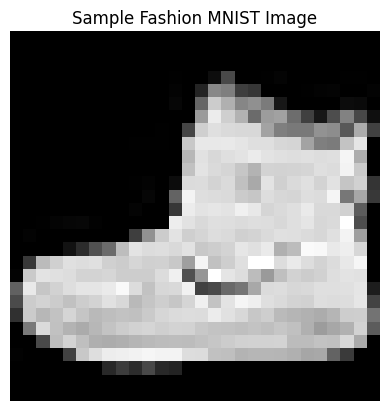

In [4]:
plt.imshow(X_train[0], cmap="gray")

plt.title("Sample Fashion MNIST Image")

plt.axis("off")

plt.show()

In [5]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [6]:
print("Minimum Pixel Value :", X_train.min())

print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


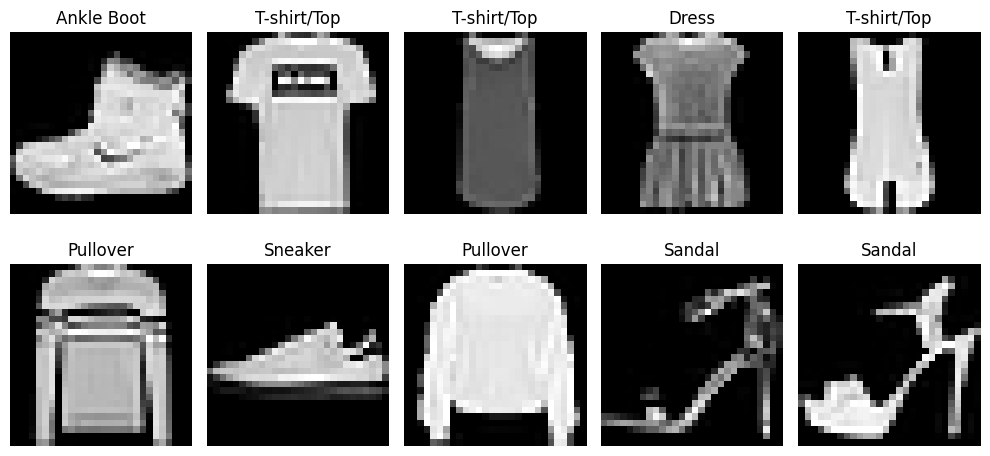

In [7]:
class_names = [

    "T-shirt/Top",

    "Trouser",

    "Pullover",

    "Dress",

    "Coat",

    "Sandal",

    "Shirt",

    "Sneaker",

    "Bag",

    "Ankle Boot"

]

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(class_names[y_train[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

Build the Baseline ANN

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [9]:
ann_model = Sequential([
    
    # Convert 28x28 image into 784 features
    Flatten(input_shape=(28, 28)),
    
    # Hidden Layer 1
    Dense(128, activation="relu"),
    
    # Hidden Layer 2
    Dense(64, activation="relu"),
    
    # Output Layer (10 Fashion MNIST classes)
    Dense(10, activation="softmax")
])

c:\installed_soft\anaconda_setup\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
ann_history = ann_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7803 - loss: 0.6259 - val_accuracy: 0.8466 - val_loss: 0.4202
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8623 - loss: 0.3749 - val_accuracy: 0.8633 - val_loss: 0.3784
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8745 - loss: 0.3396 - val_accuracy: 0.8687 - val_loss: 0.3606
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8856 - loss: 0.3089 - val_accuracy: 0.8768 - val_loss: 0.3415
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8908 - loss: 0.2942 - val_accuracy: 0.8794 - val_loss: 0.3434
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8964 - loss: 0.2748 - val_accuracy: 0.8812 - val_loss: 0.3240
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9011 - loss: 0.2643 - val_accuracy: 0.8765 - val_loss: 0.3452
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9051 - loss: 0.2515 - 

In [13]:
loss, accuracy = ann_model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8813 - loss: 0.3318
Test Loss : 0.3269851505756378
Test Accuracy : 0.8845000267028809


In [14]:
prediction = ann_model.predict(X_test[:1])

print("Predicted Class :", np.argmax(prediction))
print("Actual Class :", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Class : 9
Actual Class : 9


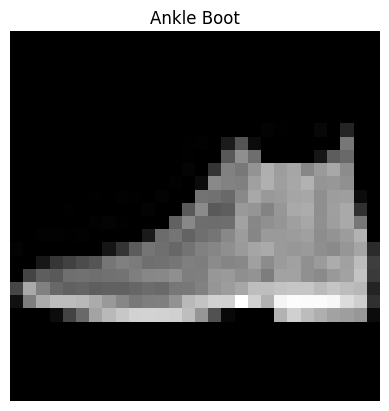

In [15]:
plt.imshow(X_test[0], cmap="gray")

plt.title(class_names[y_test[0]])

plt.axis("off")

plt.show()

Design a Convolutional Neural Network (CNN)

In [16]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)

X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print("Training Shape :", X_train_cnn.shape)

print("Testing Shape :", X_test_cnn.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [17]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [18]:
cnn_model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.25),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.25),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )

])

c:\installed_soft\anaconda_setup\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
cnn_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [21]:
cnn_history = cnn_model.fit(

    X_train_cnn,

    y_train,

    epochs=10,

    validation_data=(

        X_test_cnn,

        y_test

    )

)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6988 - loss: 0.8327 - val_accuracy: 0.8518 - val_loss: 0.4018
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8403 - loss: 0.4396 - val_accuracy: 0.8616 - val_loss: 0.3688
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8608 - loss: 0.3842 - val_accuracy: 0.8801 - val_loss: 0.3168
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8739 - loss: 0.3515 - val_accuracy: 0.8894 - val_loss: 0.3031
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8740 - loss: 0.3388 - val_accuracy: 0.8947 - val_loss: 0.2855
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8836 - loss: 0.3173 - val_accuracy: 0.8993 - val_loss: 0.2774
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8875 - loss: 0.3055 - val_accuracy: 0.9021 - val_loss: 0.2678
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8915 - loss: 

In [22]:
loss, accuracy = cnn_model.evaluate(

    X_test_cnn,

    y_test

)

print("CNN Test Loss :", loss)

print("CNN Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9047 - loss: 0.2711
CNN Test Loss : 0.26199057698249817
CNN Test Accuracy : 0.9049999713897705


In [23]:
prediction = cnn_model.predict(X_test_cnn[:1])

print("Predicted Class :", np.argmax(prediction))

print("Actual Class :", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted Class : 9
Actual Class : 9


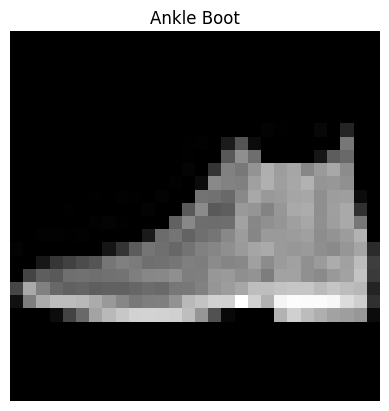

In [24]:
plt.imshow(

    X_test[0],

    cmap="gray"

)

plt.title(class_names[y_test[0]])

plt.axis("off")

plt.show()

Compare ANN and CNN Performance

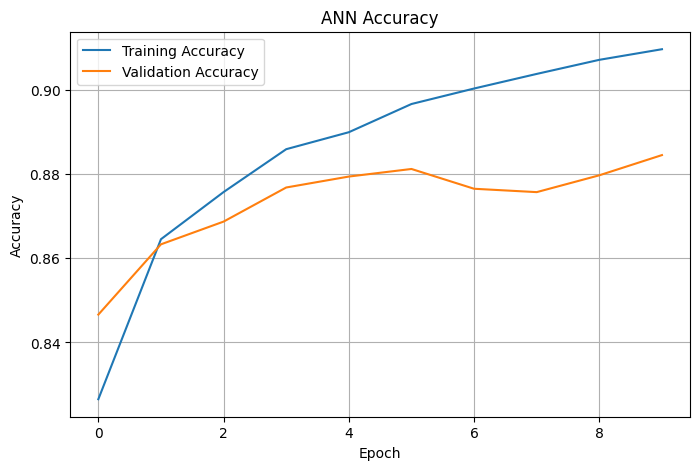

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    ann_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    ann_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

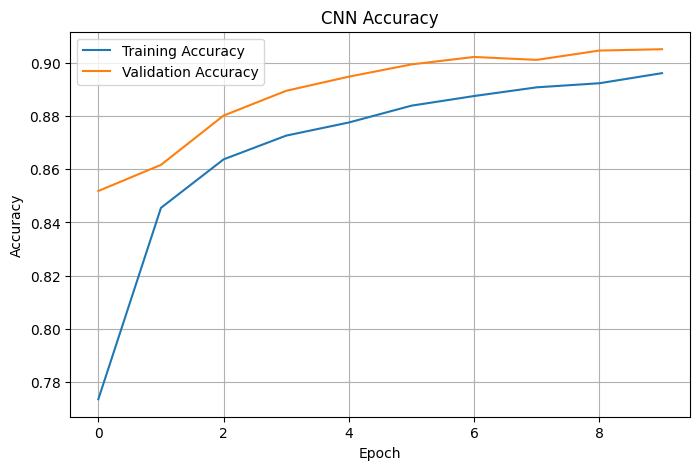

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

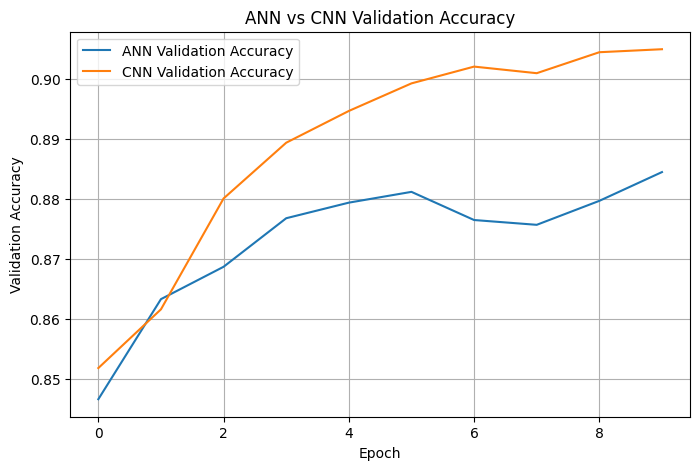

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    ann_history.history["val_accuracy"],
    label="ANN Validation Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN Validation Accuracy"
)

plt.title("ANN vs CNN Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

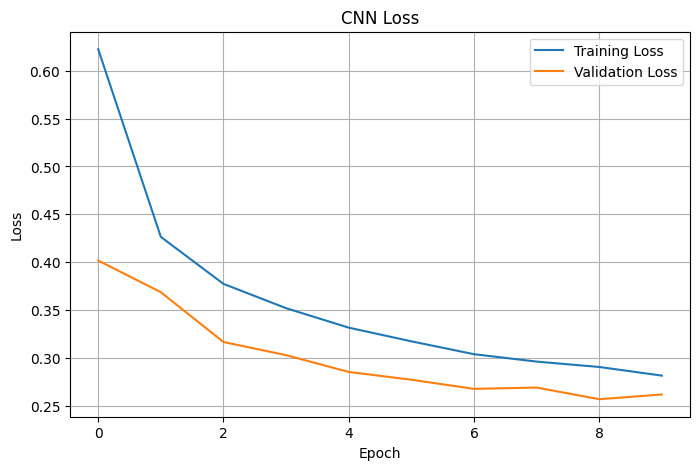

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [29]:
comparison = {
    "Model": ["ANN", "CNN"],
    "Training Accuracy": [
        ann_history.history["accuracy"][-1],
        cnn_history.history["accuracy"][-1]
    ],
    "Validation Accuracy": [
        ann_history.history["val_accuracy"][-1],
        cnn_history.history["val_accuracy"][-1]
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Training Accuracy,Validation Accuracy
0,ANN,0.909650,0.8845
1,CNN,0.896017,0.9050
